In [31]:
import numpy as np
from scipy.stats import skew
import math

In [42]:
n = 20

In [43]:
data = np.random.normal(loc = 300, scale=100, size=n)
theta_hat_mean = data.mean()

In [54]:
B = 1000
boots_means = []

In [55]:
for _ in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    boots_means.append(sample.mean())

In [56]:
emp_mean = np.mean(boots_means)
emp_mean

np.float64(294.3370818542592)

In [57]:
sum_variance = 0
for el in boots_means:
    sum_variance += (el - theta_hat_mean)**2

In [67]:
se = math.sqrt(sum_variance / (B-1))
se

15.257388504451582

In [92]:
np.std(boots_means, ddof=1) 

np.float64(15.253162235210857)

In [59]:
Z = 1.96
left_normal = theta_hat_mean - Z*se
right_normal = theta_hat_mean + Z*se

In [60]:
(left_normal, right_normal)

(np.float64(264.79151103779526), np.float64(324.6004739752455))

In [61]:
print(f"Normal Interval: [{left_normal:.3f}, {right_normal:.3f}]")

Normal Interval: [264.792, 324.600]


In [81]:
boots_means = sorted(boots_means)
alfa = 0.025

In [82]:
left_percentile = boots_means[int(alfa*B)]

In [83]:
right_percentile = boots_means[int((1-alfa)*B)]

In [87]:
print(f"Percentile Interval: [{left_percentile:.3f}, {right_percentile:.3f}]")

Percentile Interval: [266.350, 325.287]


In [88]:
np.percentile(boots_means, 2.5)

np.float64(266.3210772614476)

In [93]:
pivotal_left = 2*theta_hat_mean - left_percentile

In [95]:
pivotal_right = 2*theta_hat_mean - right_percentile

In [96]:
print(f"Pivotal Interval: [{pivotal_right:.3f}, {pivotal_left:.3f}]")

Pivotal Interval: [264.105, 323.042]


In [117]:
# Jackknife methode

In [116]:
jackknife_arr = []
for i in range(n):
    left = data[:i]
    right = data[i+1:]
    sample = np.concatenate([left, right])
    jackknife_arr.append(np.mean(sample))
    

In [121]:
jk_mean = np.mean(jackknife_arr)
jk_mean

np.float64(294.6959925065204)

In [126]:
jk_se = (n-1)/n * np.sqrt(np.sum((jackknife_arr-jk_mean)**2))

In [128]:
# Normal CI with JK

In [129]:
left_jk = theta_hat_mean - Z*jk_se
right_jk = theta_hat_mean + Z*jk_se

In [130]:
print(f"Normal JK Interval: [{left_jk:.3f}, {right_jk:.3f}]")

Normal JK Interval: [264.825, 324.567]


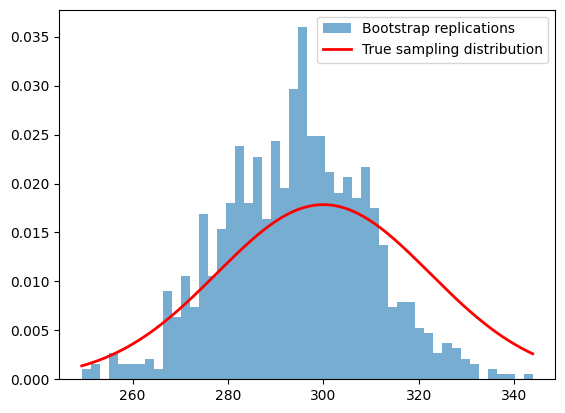

In [132]:
import matplotlib.pyplot as plt
from scipy import stats
true_mean = 300      
true_std = 100       

x = np.linspace(min(boots_means), max(boots_means), 300)
true_dist = stats.norm.pdf(x, loc=true_mean, scale=true_std/np.sqrt(n))

plt.hist(boots_means, bins=50, density=True, alpha=0.6, label='Bootstrap replications')
plt.plot(x, true_dist, 'r-', linewidth=2, label='True sampling distribution')
plt.legend()
plt.show()

In [133]:
# Estimating e^Xhat

In [145]:
mu = 5
n = 100
data = np.random.normal(loc=mu, scale=1, size = n)

In [165]:
mean_data = data.mean()
theta = np.exp(mean_data)
mean_data,theta

(np.float64(5.17933330273834), np.float64(177.5643898297502))

In [166]:
B = 1000
boot_theta_hats = []
for _ in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    mean_sample = sample.mean()
    thetha_hat = np.exp(mean_sample)
    boot_theta_hats.append(thetha_hat)

In [167]:
se_bootstrap = np.std(boot_theta_hats, ddof=1)
print(f"Bootstrap SE: {se_bootstrap:.2f}")

Bootstrap SE: 19.87


In [168]:
Z = 1.96
left_normal = theta - Z*se_bootstrap
right_normal = theta + Z*se_bootstrap
print(f"Normal Interval: [{left_normal:.3f}, {right_normal:.3f}]")

Normal Interval: [138.612, 216.516]


In [169]:
theta_hats_sorted = sorted(boot_theta_hats)
left_percentile = theta_hats_sorted[int(B*alfa)]
right_percentile = theta_hats_sorted[int(B*(1-alfa))]

In [170]:
print(f"Perceptile Interval: [{left_percentile:.3f}, {right_percentile:.3f}]")

Perceptile Interval: [143.928, 221.610]


In [ ]:
mu = 5
n = 100
data = np.random.normal(loc=mu, scale=1, size = n)
mean_data = data.mean()
theta = np.exp(mean_data)
mean_data,theta
B = 1000
boot_theta_hats = []
for _ in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    mean_sample = sample.mean()
    thetha_hat = np.exp(mean_sample)
    boot_theta_hats.append(thetha_hat)
se_bootstrap = np.std(boot_theta_hats, ddof=1)
print(f"Bootstrap SE: {se_bootstrap:.2f}")
Z = 1.96
left_normal = theta - Z*se_bootstrap
right_normal = theta + Z*se_bootstrap
print(f"Normal Interval: [{left_normal:.3f}, {right_normal:.3f}]")
theta_hats_sorted = sorted(boot_theta_hats)
left_percentile = theta_hats_sorted[int(B*alfa)]
right_percentile = theta_hats_sorted[int(B*(1-alfa))]
mu_true = 5      
sigma_true = 1     
std_hat = sigma_true/np.sqrt(n)
x = np.linspace(min(boot_theta_hats), max(boot_theta_hats), 300)
true_dist = stats.lognorm.pdf(x, s=std_hat, scale=np.exp(mu_true))

plt.hist(boot_theta_hats, bins=50, density=True, alpha=0.6, label='Bootstrap replications')
plt.plot(x, true_dist, 'r-', linewidth=2, label='True sampling distribution')
plt.legend()
plt.show()

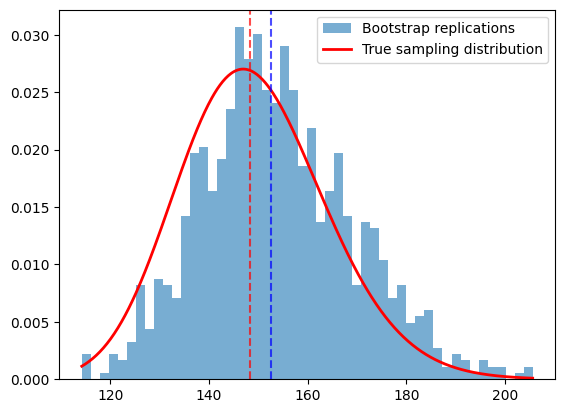

In [176]:
mu_true = 5      
sigma_true = 1     
std_hat = sigma_true/np.sqrt(n)
x = np.linspace(min(boot_theta_hats), max(boot_theta_hats), 500)
true_dist = stats.lognorm.pdf(x, s=std_hat, scale=np.exp(mu_true))

plt.hist(boot_theta_hats, bins=50, density=True, alpha=0.6, label='Bootstrap replications')
plt.plot(x, true_dist, 'r-', linewidth=2, label='True sampling distribution')
plt.axvline(theta, color='blue', linestyle='--', alpha=0.7)
plt.axvline(np.exp(mu_true), color='red', linestyle='--', alpha=0.7)

plt.legend()
plt.show()

In [177]:
print(f"Original theta: {theta:.2f} , true: {np.exp(5):.2f}")
print(f"Bootstrap SE: {se_bootstrap:.2f}")
print(f"Normal Interval: [{left_normal:.3f}, {right_normal:.3f}]")
print(f"Percentile Interval: [{left_percentile:.3f}, {right_percentile:.3f}]")


Original theta: 152.60 , true: 148.41
Bootstrap SE: 15.39
Normal Interval: [122.428, 182.763]
Percentile Interval: [126.077, 186.186]
